# 00 — Deep-notched single run

This notebook runs one `deep_notched` training with default config values, with options:

1. `task.type = "forward"/"inverse"`
2. `problem.material.law = "isotropic"/"orthotropic"`

Then it plots the final predicted fields.

In [1]:
from pathlib import Path
import importlib

import matplotlib as mpl
import matplotlib.pyplot as plt

from phd.config import load_config
import phd.models.cm.deep_notched as dn
from phd.plot import book_config, get_current_config as plt_cfg

# Ensure notebook uses latest local edits in deep_notched.py
dn = importlib.reload(dn)

book_config.set_as_current()
plot_cfg = plt_cfg()
page_width = plot_cfg.page_width if plot_cfg is not None else 7.0

save_fig = True
if save_fig:
    mpl.rcParams["pgf.texsystem"] = "pdflatex"


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not find project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
CHAPTER_DIR = PROJECT_ROOT / "chapters" / "IV_MaterialCharacterization" / "02_deep_notched"
IMAGE_DIR = CHAPTER_DIR / "images"
PDF_DIR = IMAGE_DIR / "pdf"
PDF_DIR.mkdir(parents=True, exist_ok=True)

Using backend: jax
Other supported backends: tensorflow.compat.v1, tensorflow, pytorch, paddle.
paddle supports more examples now and is recommended.
Enable just-in-time compilation with XLA.



In [2]:
def build_cfg(seed: int = 0, material_law: str = "isotropic", with_dic: bool = True, task: str = "forward"):
    cfg = load_config("deep_notched")

    cfg.seed = seed
    cfg.task.type = task
    cfg.problem.material.law = material_law

    cfg.model.net_type = "SPINN"
    cfg.model.formulation = "mixed"
    cfg.model.architecture.n_hidden = 5
    cfg.model.architecture.width = 32
    cfg.model.architecture.rank = 32
    cfg.model.architecture.activations = "tanh"
    # cfg.model.architecture.mlp_type = "modified_mlp"
    cfg.model.fourier_features.enabled = True
    cfg.model.fourier_features.n_features = 128

    cfg.training.n_iter = 20000
    cfg.training.lr = 1e-3
    cfg.training.lr_decay = ["warmup cosine", 1e-4, 1e-3, 1000, 20000, 5e-4]
    cfg.training.log_every = 100
    cfg.training.num_domain = 300 ** 2
    cfg.training.coord_normalization = True
    cfg.training.self_attention.enabled = True
    cfg.training.self_attention.share_weights = False
    # cfg.training.loss_weights = [1.0]*8 + [1e1]*2
    cfg.training.loss_normalization.scheme = "grad_norm"
    cfg.training.loss_normalization.n_warmup = 100

    cfg.problem.bc.displacement_bc_top = True #not with_dic
    cfg.problem.bc.displacement_bc_bottom = True #not with_dic
    cfg.problem.bc.corner_eps = 0.0


    cfg.results.base_dir = str(PROJECT_ROOT / "results")
    cfg.task.measurements.enabled = with_dic
    cfg.task.measurements.n_observations.x = 100
    cfg.task.measurements.n_observations.y = 100
    cfg.task.measurements.dic.region = [0.1, 0.9, 0.3, 0.7]
    cfg.task.measurements.noise_std = 1e-4

    return cfg

In [4]:
# Run or load
run_mode = "load"  # "run" or "load"

task = "forward" # "forward" or "inverse"
material_law = "isotropic"  # "isotropic" or "orthotropic"
with_dic = True  # Whether to include DIC measurements

run_name = f"{task}_{material_law}{'_with_dic' if with_dic else ''}"

if run_mode == "run":
    cfg = build_cfg(seed=0, material_law=material_law, with_dic=with_dic, task=task)
    results = dn.train(cfg)
    run_dir = dn.save_run_data(results, run_name=run_name, base_dir=cfg.results.base_dir)
elif run_mode == "load":
    results = dn.load_run(run_name, base_dir=PROJECT_ROOT / "results")
    cfg = results["config"]
else:
    raise ValueError("run_mode must be 'run' or 'load'.")

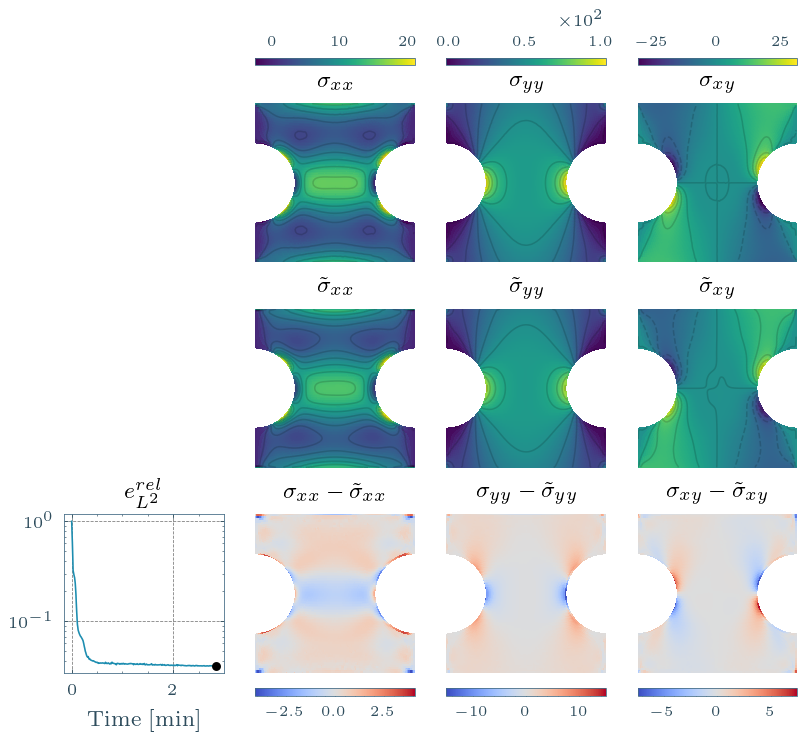

In [7]:
# Plot and save results
fig, artists = dn.plot_results(
    results,
    iteration=-1,
    step_type="time",
    time_unit="min",
    fields=["Sxx", "Syy", "Sxy"],
    plot_contours=True,
    dpi=200,
    show_metrics=True,
    show_residual=True,
    show_iter=False,
    metrics=["L2 Error"],
    side_panel="variables"
    # color_percentile=99.8,
)

if save_fig:
    fig.savefig(PDF_DIR / f"{run_name}_history.pdf", bbox_inches="tight")
    fig.savefig(IMAGE_DIR / f"{run_name}_history.png", bbox_inches="tight", dpi=300)

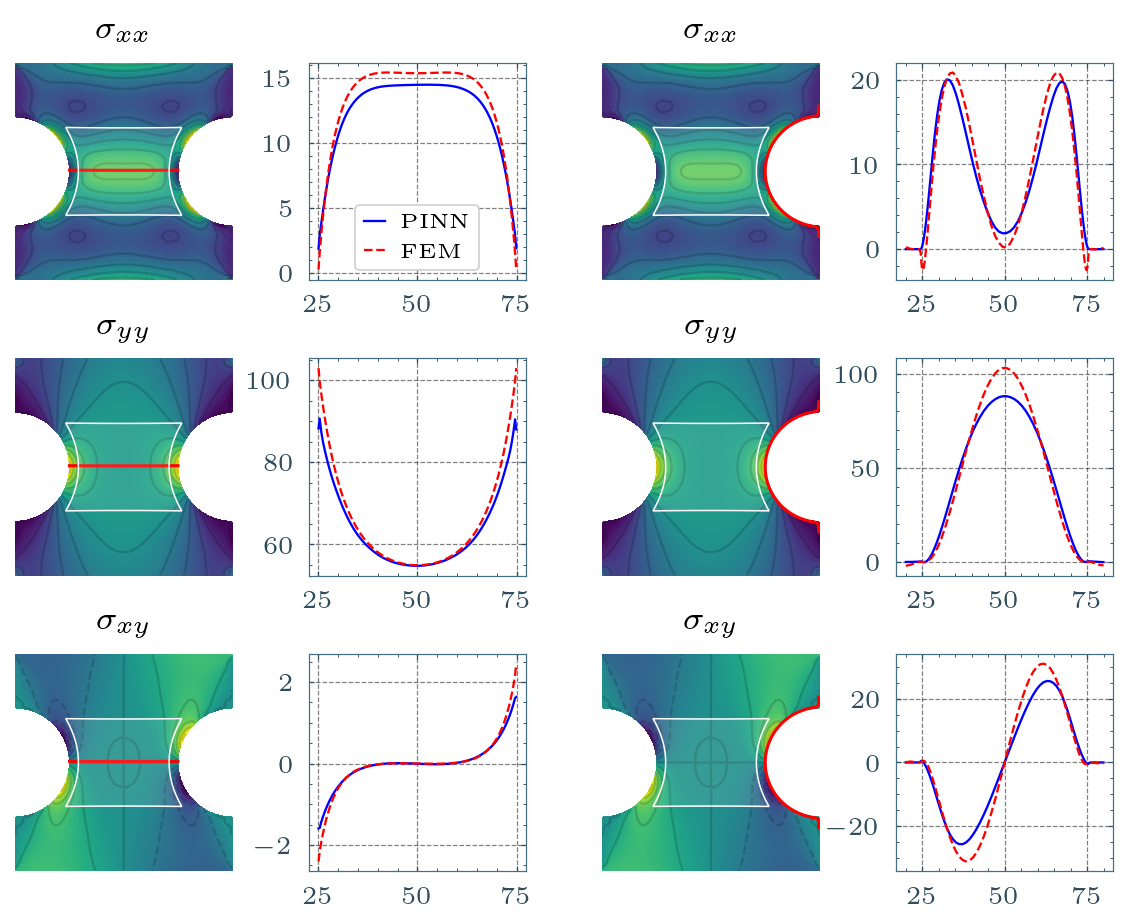

In [9]:
import importlib

import phd.plot.plot_util as plot_util
import phd.plot.plot_cm as plot_cm
import phd.plot as phd_plot
import phd.models.cm.deep_notched as dn

# Reload in dependency order so deep_notched rebinds updated plot functions
plot_util = importlib.reload(plot_util)
plot_cm = importlib.reload(plot_cm)
phd_plot = importlib.reload(phd_plot)
dn = importlib.reload(dn)

# Slice plots (mapped geometry + 1D profiles)
fig, axs = plt.subplots(3,4,figsize=(page_width, page_width * 0.75), dpi=300, gridspec_kw={'wspace': 0.35, 'hspace': 0.3})
fig_slice, ax_slice = dn.plot_slice_results(
    results,
    iteration=-1,
    fields=["Sxx", "Syy", "Sxy"],
    slice_specs=[
        {
            "direction": "horizontal",
            "value": 50.0,
            "min": 0.0,
            "max": 100.0,
            "title": "Horizontal Slice @ y=50",
        },
        {
            "direction": "vertical",
            "value": 100.0,
            "min": 20.0,
            "max": 80.0,
            "title": "Vertical Slice @ x=100",
        },
    ],
    dic_region=results["config"].task.measurements.dic.region,
    dpi=200,
    fig=fig,
    ax=axs,
    plot_contours=True,
    # color_percentile=99.7,
    
)

if save_fig:
    fig_slice.savefig(IMAGE_DIR / f"{run_name}_stress_slices.png", dpi=300, bbox_inches="tight")
    fig_slice.savefig(PDF_DIR / f"{run_name}_stress_slices.pdf", bbox_inches="tight")

plt.show()

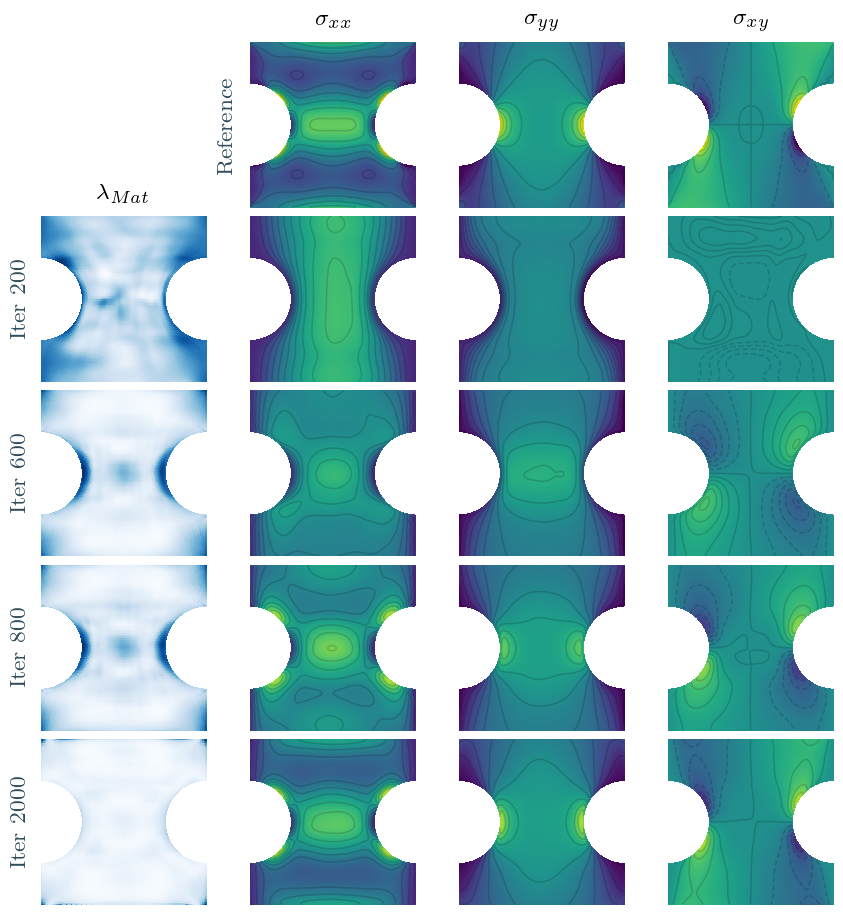

In [12]:
# Evolution figure: reference + selected iterations (SA material weight + fields)
import numpy as np
import matplotlib.pyplot as plt

# User controls
iterations_to_plot = [0, 600, 800, 2000]
fields_to_plot = ["Sxx", "Syy", "Sxy"]

# Reuse the same mesh transform and exact-solution logic as deep_notched plotting wrappers
exact_fn = lambda x_input, lmbd=None, mu=None, Q=None, net_type="SPINN": dn.exact_solution(
    x_input, cfg=results["config"]
)
mesh_transform = dn._plot_mesh_transform_from_cfg(results["config"])

steps, _, _, fields_init, get_snapshot_fn, (Xmesh, Ymesh), (Xeval, Yeval), _, _ = plot_cm.process_results(
    results,
    exact_solution_fn=exact_fn,
    plot_fields=fields_to_plot,
    mesh_transform=mesh_transform,
)

# Map requested iterations to nearest available field snapshot
def nearest_step_index(step_array, target_step):
    idx = int(np.searchsorted(step_array, target_step, side="left"))
    if idx <= 0:
        return 0
    if idx >= len(step_array):
        return len(step_array) - 1
    return idx if abs(step_array[idx] - target_step) < abs(step_array[idx - 1] - target_step) else idx - 1

frame_indices = [nearest_step_index(steps, it) for it in iterations_to_plot]
actual_iterations = [int(steps[i]) for i in frame_indices]

# Prepare SA material-weight snapshots (fallback to PDE weights if shared)
weight_steps, weight_hist_dict = plot_cm._extract_variable_array_history(results)
mat_weight_hist = None
if weight_hist_dict:
    mat_weight_hist = weight_hist_dict.get("mat_weights", None)
    if mat_weight_hist is None:
        mat_weight_hist = weight_hist_dict.get("pde_weights", None)

mat_weight_grid_hist = None
if mat_weight_hist is not None:
    mat_weight_grid_hist = plot_cm._interpolate_weight_history_to_grid(
        mat_weight_hist,
        Xeval,
        Yeval,
        float(np.nanmin(Xeval)),
        float(np.nanmax(Xeval)),
        float(np.nanmin(Yeval)),
        float(np.nanmax(Yeval)),
    )

n_rows = 1 + len(frame_indices)  # reference row + iteration rows
n_cols = 1 + len(fields_to_plot)  # SA mat weight + selected fields
fig_width = page_width * 0.9
fig_height = fig_width * (n_rows / n_cols) * 0.95
fig, ax = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height), dpi=200)
ax = np.atleast_2d(ax)

# Keep consistent color limits per field using reference values
field_limits = {}
for field in fields_to_plot:
    ref_data = np.asarray(fields_init[field]["data"][0])
    field_limits[field] = (float(np.nanmin(ref_data)), float(np.nanmax(ref_data)))

weight_vmin = weight_vmax = None
if mat_weight_grid_hist is not None and len(mat_weight_grid_hist) > 0:
    weight_vmin = float(np.nanmin(mat_weight_grid_hist))
    weight_vmax = float(np.nanmax(mat_weight_grid_hist))

# Row 0: reference fields
ax[0, 0].set_axis_off()
# ax[0, 0].text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=plot_cfg.min_font_size)
ax[1, 0].set_title(r"$\lambda_{Mat}$")
ax[0, 1].set_ylabel("Reference", fontsize=plot_cfg.title_font_size, labelpad=5)

field_mappables = {}
for c, field in enumerate(fields_to_plot, start=1):
    vmin, vmax = field_limits[field]
    art_ref = plot_util.plot_field(
        ax[0, c],
        Xmesh,
        Ymesh,
        fields_init[field]["data"][0],
        title=plot_cm.LATEX_FIELD_NAMES.get(field, field),
        cmap="viridis",
        plot_contours=True,
        vmin=vmin,
        vmax=vmax,
    )
    field_mappables[field] = art_ref["im"]

weight_mappable = None

# Rows 1..N: each selected iteration
for r, (frame_idx, iter_val) in enumerate(zip(frame_indices, actual_iterations), start=1):
    ax[r, 0].set_ylabel(f"Iter {iter_val}", fontsize=plot_cfg.title_font_size)

    if mat_weight_grid_hist is None or weight_steps is None:
        ax[r, 0].set_axis_off()
        ax[r, 0].text(0.5, 0.5, "No SA weights", ha="center", va="center", fontsize=plot_cfg.min_font_size)
    else:
        w_idx = plot_cm._weight_frame_index(iter_val, weight_steps)
        w_grid = mat_weight_grid_hist[w_idx]
        art_w = plot_util.plot_field(
            ax[r, 0],
            Xmesh,
            Ymesh,
            w_grid,
            cmap="Blues",
            plot_contours=False,
            # vmin=weight_vmin,
            # vmax=weight_vmax,
        )
        if weight_mappable is None:
            weight_mappable = art_w["im"]

    snapshot = get_snapshot_fn(frame_idx)
    for c, field in enumerate(fields_to_plot, start=1):
        vmin, vmax = field_limits[field]
        pred_grid = snapshot[field][1]
        plot_util.plot_field(
            ax[r, c],
            Xmesh,
            Ymesh,
            pred_grid,
            cmap="viridis",
            plot_contours=True,
            vmin=vmin,
            vmax=vmax,
        )

# Finalize subplot geometry first, then place colorbars using the full column slot width.
fig.subplots_adjust(left=0.03, right=0.995, top=0.985, bottom=0.13, wspace=0.08, hspace=0.05)


def add_column_colorbar(fig, ax_grid, col_idx, mappable, pad=0.020, height=0.008):
    col_slot = ax_grid[-1, col_idx].get_subplotspec().get_position(fig)
    cax = fig.add_axes([col_slot.x0, col_slot.y0 - pad - height, col_slot.width, height])
    cb = fig.colorbar(mappable, cax=cax, orientation="horizontal", format=plot_util.make_formatter())
    cb.ax.tick_params(labelsize=plot_cfg.min_font_size, length=1)
    return cb


# Column-aligned colorbars (one for SA weight + one per field)
# if weight_mappable is not None:
#     add_column_colorbar(fig, ax, 0, weight_mappable)
# for c, field in enumerate(fields_to_plot, start=1):
#     add_column_colorbar(fig, ax, c, field_mappables[field])

if save_fig:
    evolution_name = f"{run_name}_weights_evolution"
    fig.savefig(IMAGE_DIR / f"{evolution_name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(PDF_DIR / f"{evolution_name}.pdf", bbox_inches="tight")

plt.show()